# Results


<b> Objective: </b>
Aggregate the cached experiment results into the statistics the report quotes, and measure how
each element correlates with the geophysical fields and with the rest of the chemistry

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>

### Imports

In [14]:
import sys
import os
COLAB_SESSION = False

DRIVE_PATH = ""
if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from GreenlandUtils import lonlatToUTM24N, Printable

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)

### Setup

Unlike the other three notebooks, this one loads **both datasets at once** — its whole purpose is
to compare them, so switching a constant would defeat it.

It also **never trains anything**. Every score is read from the JSON cache in `Results/`; if a file
is missing the corresponding row is simply absent rather than recomputed. The only raw data it
touches is `Data.csv`, which it needs for the correlation sections at the end.

In [15]:
DATASETS = ["Whole Rock", "Stream Sediment"]
SOURCE_CSV = { "Whole Rock": "whole-rock", "Stream Sediment": "stream-sediment" }
MERGE_TYPE = "Mean Merge"
MODEL = "HistGradientBoosting"

#The reportable target set: every element with at least this many measurements. The unsuffixed
#files use the ten best-covered elements instead, which is the cut the report argues against.
MIN_TARGET_COVERAGE = 1000
TARGET_SUFFIX = "_Cov1000"
MIN_COVERAGE = 10

NEIGHBOUR_K = 20


def DataPath(dataset: str) -> str:
    return f"{DRIVE_PATH}Data/{dataset}/{MERGE_TYPE}/"


def ResultsPath(dataset: str) -> str:
    return f"{DRIVE_PATH}Results/{dataset}/{MERGE_TYPE}/"


def LoadResults(dataset: str, baseName: str) -> dict:
    """Cached results only. A missing file returns None instead of raising."""
    path = f"{ResultsPath(dataset)}{baseName}.json"
    if not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)


def LoadDataset(dataset: str) -> dict:
    df = pd.read_csv(f"{DataPath(dataset)}Data.csv", delimiter=";", low_memory=False)

    with open(f"{DRIVE_PATH}Data/{SOURCE_CSV[dataset]}.json", "r") as f:
        schema = json.load(f)

    #Same derivation as notebook 2, so the element list here matches the one that was trained on
    elementCols = [col for col in df.columns if col not in schema["metaCols"] + schema["physicalCols"]]
    coverage = df[elementCols].notna().sum()
    elementCols = [col for col in elementCols if coverage[col] >= MIN_COVERAGE]
    targets = [col for col in elementCols if coverage[col] >= MIN_TARGET_COVERAGE]

    return {
        "df": df,
        "coverage": coverage,
        "elementCols": elementCols,
        "targets": targets,
        "physicalCols": schema["physicalCols"],
        "locationCols": schema["locationCols"],
    }


data = { dataset: LoadDataset(dataset) for dataset in DATASETS }

printable = Printable()
printable.title("Loaded")
for dataset in DATASETS:
    entry = data[dataset]
    printable.add(dataset, f"{len(entry['df']):>6} samples   {len(entry['elementCols']):>3} elements   "
                           f"{len(entry['targets']):>3} targets (coverage >= {MIN_TARGET_COVERAGE})")
printable.flush()

============================== Loaded ==============================
Whole Rock:          6957 samples    68 elements    48 targets (coverage >= 1000)
Stream Sediment:    17463 samples    87 elements    71 targets (coverage >= 1000)


### Headline Comparison

Every feature set and neighbour encoding, both datasets, on the coverage-threshold target set.

`delta` is the change over own chemistry; `sigma` expresses it in units of that dataset's fold
standard deviation, which is the noise floor below which a difference should not be read as real.

In [16]:
def MeanR2(results: dict, elements: list[str] = None) -> float:
    scores = [score["r2"] for element, score in results.items()
              if score.get("r2") is not None and (elements is None or element in elements)]
    return float(np.mean(scores)) if scores else float("nan")


def MeanFoldStd(results: dict, elements: list[str] = None) -> float:
    spreads = [score["r2_std"] for element, score in results.items()
               if score.get("r2_std") is not None and (elements is None or element in elements)]
    return float(np.mean(spreads)) if spreads else float("nan")


FEATURE_SETS = {
    "Chemistry":                f"{MODEL}_KFold_FeatureSet_Chemistry{TARGET_SUFFIX}",
    "Geophysics":               f"{MODEL}_KFold_FeatureSet_Physics{TARGET_SUFFIX}",
    "Coordinates":              f"{MODEL}_KFold_FeatureSet_Location{TARGET_SUFFIX}",
    "Neighbours":               f"{MODEL}_KFold_FeatureSet_Neighbours{TARGET_SUFFIX}",
    "Chemistry + Geophysics":   f"{MODEL}_KFold_FeatureSet_Chemistry_Physics{TARGET_SUFFIX}",
    "Chemistry + Coordinates":  f"{MODEL}_KFold_FeatureSet_Chemistry_Location{TARGET_SUFFIX}",
    "Geophysics + Coordinates": f"{MODEL}_KFold_FeatureSet_Physics_Location{TARGET_SUFFIX}",
}

KNN_VARIANTS = { f"KNN {variant}": f"{MODEL}_KFold_KNN_{variant}_ExcludingColocation{TARGET_SUFFIX}"
                 for variant in "ABCD" }

REFERENCE = "Chemistry"


def HeadlineTable(rows: dict[str, str]) -> pd.DataFrame:
    """One row per configuration, one column block per dataset."""

    table = {}
    for dataset in DATASETS:
        reference = LoadResults(dataset, FEATURE_SETS[REFERENCE])
        baseline = MeanR2(reference)
        noise = MeanFoldStd(reference)

        column = {}
        for name, baseName in rows.items():
            results = LoadResults(dataset, baseName)
            if results is None:
                column[name] = (np.nan, np.nan, np.nan)
                continue
            score = MeanR2(results)
            column[name] = (score, score - baseline, (score - baseline) / noise)

        table[dataset] = column

    frame = pd.DataFrame({
        (dataset, field): { name: values[i] for name, values in table[dataset].items() }
        for dataset in DATASETS
        for i, field in enumerate(["R2", "delta", "sigma"])
    })
    frame.columns = pd.MultiIndex.from_tuples(frame.columns)

    return frame


headline = HeadlineTable({**FEATURE_SETS, **KNN_VARIANTS})

printable = Printable()
printable.title("Noise floor (mean across-fold std of R2)")
for dataset in DATASETS:
    printable.add(dataset, f"{MeanFoldStd(LoadResults(dataset, FEATURE_SETS[REFERENCE])):.4f}")
printable.flush()

display(headline.round(4))

======== Noise floor (mean across-fold std of R2) ========
Whole Rock:        0.0180
Stream Sediment:   0.0137


Whole Rock                  Stream Sediment                 
                                 R2   delta    sigma              R2   delta    sigma
Chemistry                    0.7983  0.0000   0.0000          0.8676  0.0000   0.0000
Geophysics                   0.3228 -0.4755 -26.3708          0.5253 -0.3423 -24.9392
Coordinates                  0.3484 -0.4499 -24.9507          0.5994 -0.2682 -19.5411
Neighbours                   0.3246 -0.4737 -26.2732          0.6086 -0.2590 -18.8694
Chemistry + Geophysics       0.8059  0.0075   0.4183          0.8739  0.0063   0.4575
Chemistry + Coordinates      0.8063  0.0080   0.4445          0.8775  0.0099   0.7218
Geophysics + Coordinates     0.3546 -0.4437 -24.6081          0.6017 -0.2659 -19.3727
KNN A                        0.8043  0.0059   0.3294          0.8757  0.0081   0.5906
KNN B                        0.8050  0.0066   0.3685          0.8724  0.0048   0.3495
KNN C                        0.8132  0.0149   0.8239          0.8801  0.0125   0.9127
KNN D                        0.7982 -0.0001  -0.0051          0.8659 -0.0017  -0.1214

### Where the Gain Lands

The pooled mean above is an average over targets that behave very differently. Binning targets by
their **own baseline score** separates the elements own chemistry already predicts from the ones it
cannot, and scores each added source inside each bin.

Neighbours are taken from the KNN variant C results rather than the `Neighbours` feature set: that
set replaces own chemistry, where the question here is what each source adds *on top of* it.

In [17]:
DIFFICULTY_BINS = [(0.00, 0.70), (0.70, 0.85), (0.85, 0.95), (0.95, 1.01)]


def BinLabel(low: float, high: float, bins: list[tuple[float, float]]) -> str:
    if (low, high) == bins[0]:
        return f"under {high:.2f}"
    if (low, high) == bins[-1]:
        return f"over {low:.2f}"
    return f"{low:.2f} - {high:.2f}"


def GainByDifficulty(dataset: str, bins: list[tuple[float, float]] = DIFFICULTY_BINS) -> pd.DataFrame:

    reference = LoadResults(dataset, FEATURE_SETS[REFERENCE])
    sources = {
        "+ neighbours":  LoadResults(dataset, KNN_VARIANTS["KNN C"]),
        "+ geophysics":  LoadResults(dataset, FEATURE_SETS["Chemistry + Geophysics"]),
        "+ coordinates": LoadResults(dataset, FEATURE_SETS["Chemistry + Coordinates"]),
    }

    rows = []
    for low, high in bins:
        elements = [element for element, score in reference.items()
                    if score["r2"] is not None and low <= score["r2"] < high]
        if not elements:
            continue

        row = { "band": BinLabel(low, high, bins), "n": len(elements),
                "baseline": MeanR2(reference, elements) }
        for name, results in sources.items():
            #An element missing from a source is skipped rather than counted as a zero gain
            gains = [results[element]["r2"] - reference[element]["r2"] for element in elements
                     if results.get(element, {}).get("r2") is not None]
            row[name] = float(np.mean(gains)) if gains else np.nan

        rows.append(row)

    return pd.DataFrame(rows).set_index("band")


for dataset in DATASETS:
    print(f"=== {dataset} ===")
    display(GainByDifficulty(dataset).round(4))

=== Whole Rock ===


,n,baseline,+ neighbours,+ geophysics,+ coordinates
band,,,,,
under 0.70,8,0.5920,0.0517,0.0238,0.0219
0.70 - 0.85,23,0.7927,0.0102,0.0058,0.0070
0.85 - 0.95,14,0.8909,0.0044,0.0026,0.0034
over 0.95,3,0.9597,0.0008,0.0007,0.0003


=== Stream Sediment ===


,n,baseline,+ neighbours,+ geophysics,+ coordinates
band,,,,,
under 0.70,8,0.5846,0.0484,0.0291,0.0421
0.70 - 0.85,13,0.7896,0.0211,0.0084,0.0150
0.85 - 0.95,30,0.9076,0.0075,0.0032,0.0051
over 0.95,20,0.9714,0.0001,0.0004,0.0009


### Per-Element Detail

Which elements own chemistry predicts well, which it does not, and which gain most from a
neighbourhood. `coverage` is how many samples measured the element at all.

In [18]:
def PerElement(dataset: str) -> pd.DataFrame:

    reference = LoadResults(dataset, FEATURE_SETS[REFERENCE])
    neighbours = LoadResults(dataset, KNN_VARIANTS["KNN C"])
    geophysics = LoadResults(dataset, FEATURE_SETS["Chemistry + Geophysics"])
    coverage = data[dataset]["coverage"]

    rows = []
    for element, score in reference.items():
        if score["r2"] is None:
            continue
        rows.append({
            "element": element,
            "coverage": int(coverage.get(element, 0)),
            "baseline": score["r2"],
            "fold_std": score.get("r2_std", np.nan),
            "+neighbours": neighbours.get(element, {}).get("r2", np.nan) - score["r2"],
            "+geophysics": geophysics.get(element, {}).get("r2", np.nan) - score["r2"],
        })

    return pd.DataFrame(rows).set_index("element")


perElement = { dataset: PerElement(dataset) for dataset in DATASETS }

for dataset in DATASETS:
    frame = perElement[dataset]
    print(f"=== {dataset}: largest neighbour gain ===")
    display(frame.sort_values("+neighbours", ascending=False).head(10).round(4))
    print(f"=== {dataset}: hardest to predict from own chemistry ===")
    display(frame.sort_values("baseline").head(8).round(4))

=== Whole Rock: largest neighbour gain ===


,coverage,baseline,fold_std,+neighbours,+geophysics
element,,,,,
As ppm,2355,0.5300,0.0191,0.0959,0.0373
Au ppb,2389,0.4894,0.0547,0.0921,0.0458
Sb ppm,2102,0.5477,0.0461,0.0704,0.0191
Cs ppm,1750,0.5689,0.0137,0.0476,0.0270
S ppm,1304,0.6706,0.0429,0.0405,0.0267
Pb ppm,3429,0.6787,0.0376,0.0267,0.0088
Cu ppm,4991,0.6497,0.0181,0.0262,0.0145
Rb ppm,4484,0.7578,0.0180,0.0234,0.0087
Sr ppm,5591,0.7969,0.0159,0.0175,0.0085


=== Whole Rock: hardest to predict from own chemistry ===


,coverage,baseline,fold_std,+neighbours,+geophysics
element,,,,,
Au ppb,2389,0.4894,0.0547,0.0921,0.0458
As ppm,2355,0.5300,0.0191,0.0959,0.0373
Sb ppm,2102,0.5477,0.0461,0.0704,0.0191
Cs ppm,1750,0.5689,0.0137,0.0476,0.0270
Mo ppm,1975,0.6008,0.0229,0.0146,0.0113
Cu ppm,4991,0.6497,0.0181,0.0262,0.0145
S ppm,1304,0.6706,0.0429,0.0405,0.0267
Pb ppm,3429,0.6787,0.0376,0.0267,0.0088


=== Stream Sediment: largest neighbour gain ===


,coverage,baseline,fold_std,+neighbours,+geophysics
element,,,,,
U ppm,14831,0.5937,0.0330,0.2205,0.1870
As ppm,6873,0.6069,0.0191,0.0599,0.0130
Br ppm,9973,0.7729,0.0069,0.0434,0.0242
Sb ppm,6033,0.6612,0.0157,0.0406,0.0105
Pb ppm,12527,0.6411,0.0185,0.0343,0.0088
Cs ppm,6748,0.7581,0.0139,0.0313,0.0093
Ca %,13354,0.8151,0.0111,0.0307,0.0144
Zn ppm,16123,0.7812,0.0078,0.0298,0.0131
Sr ppm,14389,0.8402,0.0127,0.0275,0.0111


=== Stream Sediment: hardest to predict from own chemistry ===


,coverage,baseline,fold_std,+neighbours,+geophysics
element,,,,,
Au ppb,2551,0.1281,0.0614,0.0204,0.0097
U ppm,14831,0.5937,0.0330,0.2205,0.1870
As ppm,6873,0.6069,0.0191,0.0599,0.0130
Pb ppm,12527,0.6411,0.0185,0.0343,0.0088
Sb ppm,6033,0.6612,0.0157,0.0406,0.0105
S %,3502,0.6716,0.0245,0.0174,0.0113
V ppm,14078,0.6799,0.0123,0.0012,-0.0015
Ta ppm,3861,0.6945,0.0448,-0.0072,-0.0058


### Neighbourhood Size

The $k$-sweep runs on the ten best-covered elements rather than the full target set, so its levels
are not comparable with the tables above — the shape is what it establishes.

In [19]:
SWEEPS = [1, 3, 5, 10, 20, 50, 100]


def KSweepTable(dataset: str) -> pd.DataFrame:

    baseline = MeanR2(LoadResults(dataset, f"{MODEL}_KFold"))

    rows = {}
    for k in SWEEPS:
        row = {}
        for variant in "ABCD":
            results = LoadResults(dataset, f"K-Sweep_{k}_{variant}")
            row[variant] = MeanR2(results) - baseline if results else np.nan
        rows[k] = row

    frame = pd.DataFrame(rows).T
    frame.index.name = "k"
    return frame


for dataset in DATASETS:
    print(f"=== {dataset}: change over baseline, top-10 targets ===")
    display(KSweepTable(dataset).round(4))

=== Whole Rock: change over baseline, top-10 targets ===


,A,B,C,D
k,,,,
1,0.0016,0.0016,0.0020,0.0020
3,0.0027,0.0028,0.0048,0.0007
5,0.0033,0.0033,0.0064,-0.0002
10,0.0035,0.0033,0.0082,-0.0013
20,0.0037,0.0027,0.0102,-0.0035
50,0.0041,0.0013,0.0112,-0.0054
100,0.0043,-0.0012,0.0116,-0.0079


=== Stream Sediment: change over baseline, top-10 targets ===


,A,B,C,D
k,,,,
1,0.0186,0.0186,0.0221,0.0221
3,0.0248,0.0216,0.0279,0.0216
5,0.0270,0.0224,0.0297,0.0199
10,0.0276,0.0213,0.0327,0.0174
20,0.0279,0.0192,0.0347,0.0158
50,0.0282,0.0153,0.0355,0.0112
100,0.0230,0.0132,0.0353,0.0087


### Graph Network

Stream sediment only. The comparison that matters is against variant C at the same $k$, not against
the no-neighbour baseline — the network has to beat the encoding it replaces.

In [20]:
def GNNTable(dataset: str = "Stream Sediment") -> pd.DataFrame:

    baseline = MeanR2(LoadResults(dataset, f"{MODEL}_KFold"))

    rows = {}
    for k in SWEEPS:
        row = {}
        for name, template in [("GAT", "GNN_GAT_KFold_k{k}"), ("SAGE", "GNN_SAGE_KFold_k{k}")]:
            results = LoadResults(dataset, template.format(k=k))
            row[name] = MeanR2(results) if results else np.nan
        handBuilt = LoadResults(dataset, f"K-Sweep_{k}_C")
        row["Variant C"] = MeanR2(handBuilt) if handBuilt else np.nan
        row["SAGE - GAT"] = row["SAGE"] - row["GAT"]
        rows[k] = row

    frame = pd.DataFrame(rows).T
    frame.index.name = "k"
    return frame


print(f"baseline (own chemistry, top-10): {MeanR2(LoadResults('Stream Sediment', f'{MODEL}_KFold')):.4f}")
display(GNNTable().round(4))

#The settled configuration is the one the report quotes: SAGE at k=20 on the full target set
settled = LoadResults("Stream Sediment", f"GNN_SAGE_KFold_k{NEIGHBOUR_K}{TARGET_SUFFIX}")
if settled is not None:
    reference = LoadResults("Stream Sediment", FEATURE_SETS[REFERENCE])
    handBuilt = LoadResults("Stream Sediment", KNN_VARIANTS["KNN C"])

    printable = Printable()
    printable.title(f"Settled configuration (SAGE, k={NEIGHBOUR_K}, {len(settled)} targets)")
    printable.add("tabular chemistry", f"{MeanR2(reference):.4f}")
    printable.add("tabular KNN C", f"{MeanR2(handBuilt):.4f}")
    printable.add("GNN", f"{MeanR2(settled):.4f}")
    printable.rest()

    #Sum wt% is an arithmetic identity and the network handles it pathologically, so the
    #comparison is reported with and without it
    trimmed = [e for e in reference if e != "Sum wt%"]
    printable.add("excluding Sum wt%", "")
    printable.add("   tabular chemistry", f"{MeanR2(reference, trimmed):.4f}")
    printable.add("   tabular KNN C", f"{MeanR2(handBuilt, trimmed):.4f}")
    printable.add("   GNN", f"{MeanR2(settled, trimmed):.4f}")
    printable.flush()

baseline (own chemistry, top-10): 0.7988


,GAT,SAGE,Variant C,SAGE - GAT
k,,,,
1,0.8043,0.7918,0.8209,-0.0126
3,0.8125,0.8090,0.8267,-0.0035
5,0.8188,0.8182,0.8285,-0.0005
10,0.8208,0.8216,0.8315,0.0008
20,0.8205,0.8260,0.8335,0.0054
50,0.8138,0.8255,0.8342,0.0117
100,0.8091,0.8231,0.8340,0.0140


=========== Settled configuration (SAGE, k=20, 71 targets) ===========
tabular chemistry:      0.8676
tabular KNN C:          0.8801
GNN:                    0.8676


excluding Sum wt%:      
   tabular chemistry:   0.8659
   tabular KNN C:       0.8787
   GNN:                 0.8696


### Correlations with Geophysics

For each geophysical field, the elements whose concentration tracks it most closely. Easting and
northing are included as **controls**, not as results: a field that beats raw position is carrying
something position does not, and one that does not is a position proxy.

Correlations are pairwise-complete on the log10 concentrations, and pairs with fewer than
`MIN_PAIRS` shared samples are dropped — a large coefficient on 40 samples is not a finding.

In [21]:
MIN_PAIRS = 100
TOP_N = 8

EASTING, NORTHING = "(easting)", "(northing)"


def BuildPredictors(dataset: str) -> dict[str, np.ndarray]:
    """The geophysical grids, plus projected position as a control."""

    entry = data[dataset]
    df = entry["df"]

    x, y = lonlatToUTM24N(df["Longitude"].to_numpy(float), df["Latitude"].to_numpy(float))

    predictors = { col: df[col].to_numpy(float) for col in entry["physicalCols"] }
    predictors[EASTING] = x
    predictors[NORTHING] = y

    return predictors


def CorrelateAgainst(dataset: str, predictors: dict[str, np.ndarray], minPairs: int = MIN_PAIRS) -> pd.DataFrame:

    entry = data[dataset]
    df = entry["df"]

    rows = []
    for name, values in predictors.items():
        values = np.asarray(values, dtype=float)

        for element in entry["elementCols"]:
            target = df[element].to_numpy(dtype=float)
            paired = np.isfinite(target) & np.isfinite(values)
            if paired.sum() < minPairs:
                continue

            rows.append({
                "predictor": name,
                "element": element,
                "n": int(paired.sum()),
                "pearson": pearsonr(values[paired], target[paired])[0],
                "spearman": spearmanr(values[paired], target[paired])[0],
            })

    frame = pd.DataFrame(rows)
    frame["abs_spearman"] = frame["spearman"].abs()
    return frame


geoCorrelations = {}
for dataset in DATASETS:
    geoCorrelations[dataset] = CorrelateAgainst(dataset, BuildPredictors(dataset))

    print(f"=== {dataset} ===")
    for name in list(BuildPredictors(dataset)):
        subset = geoCorrelations[dataset]
        subset = subset[subset["predictor"] == name].nlargest(TOP_N, "abs_spearman")
        print(f"--- {name} ---")
        display(subset[["element", "n", "pearson", "spearman"]]
                .set_index("element").round(3))

=== Whole Rock ===
--- geo_magnetic_anomaly nT ---


,n,pearson,spearman
element,,,
C wt%,101,0.596,0.481
U ppm,3227,0.283,0.284
Zr ppm,3502,0.204,0.207
Nb ppm,1978,0.204,0.206
Co ppm,4378,-0.193,-0.197
Se ppm,305,-0.197,-0.193
Tm ppm,412,0.178,0.181
Ho ppm,433,0.132,0.177


--- geo_heat_flow mW/m2 ---


,n,pearson,spearman
element,,,
C wt%,101,-0.780,-0.688
Sn ppm,443,0.497,0.503
Se ppm,305,0.264,0.280
Br ppm,715,-0.272,-0.268
Ge ppm,288,-0.184,-0.268
Er ppm,444,-0.252,-0.233
Tm ppm,412,-0.242,-0.222
W ppm,1815,0.166,0.208


--- geo_depth_to_moho km ---


...

,n,pearson,spearman
element,,,
Be ppm,1722,0.681,0.699
Cd ppm,1750,0.659,0.663
Bi ppm,943,0.736,0.640
Ag ppm,2401,0.630,0.639
Ge ppm,1372,0.674,0.629
Na %,11692,0.495,0.617
S ppm,128,0.267,0.575
Al %,4041,0.494,0.491


--- (easting) ---


,n,pearson,spearman
element,,,
Ge ppm,1372,0.820,0.759
Sn ppm,1739,0.646,0.719
Na %,11692,-0.378,-0.508
Tm ppm,1396,0.516,0.508
Se ppm,923,0.689,0.505
Er ppm,1400,0.479,0.486
Ho ppm,1394,0.474,0.469
S ppm,128,-0.282,-0.450


--- (northing) ---


,n,pearson,spearman
element,,,
Ge ppm,1372,0.675,0.785
W ppm,2492,0.823,0.783
Bi ppm,943,0.807,0.781
Sn ppm,1739,0.558,0.772
Cd ppm,1750,0.708,0.752
Be ppm,1722,0.674,0.745
Se ppm,923,0.860,0.701
Ag ppm,2401,0.630,0.689


#### Is geophysics more than a position proxy?

For every element, the strongest geophysical correlation is compared against the strongest
correlation with raw easting or northing. The share of elements where geophysics wins is the
statistic the report quotes.

In [22]:
def PositionProxyTest(dataset: str) -> tuple[pd.DataFrame, dict]:

    frame = geoCorrelations[dataset]
    geoNames = data[dataset]["physicalCols"]

    best = {}
    for element, group in frame.groupby("element"):
        physics = group[group["predictor"].isin(geoNames)]
        position = group[group["predictor"].isin([EASTING, NORTHING])]
        if physics.empty or position.empty:
            continue

        physicsBest = physics.loc[physics["abs_spearman"].idxmax()]
        positionBest = position.loc[position["abs_spearman"].idxmax()]

        best[element] = {
            "best_field": physicsBest["predictor"],
            "field_spearman": physicsBest["spearman"],
            "best_position": positionBest["predictor"],
            "position_spearman": positionBest["spearman"],
            "margin": physicsBest["abs_spearman"] - positionBest["abs_spearman"],
        }

    table = pd.DataFrame(best).T
    wins = (table["margin"] > 0).sum()

    summary = {
        "elements": len(table),
        "geophysics_wins": int(wins),
        "share": wins / len(table) if len(table) else np.nan,
        "median_abs_northing": frame[frame["predictor"] == NORTHING]["abs_spearman"].median(),
    }

    return table, summary


printable = Printable()
printable.title("Geophysics versus raw position")
for dataset in DATASETS:
    table, summary = PositionProxyTest(dataset)
    printable.add(dataset, f"{summary['geophysics_wins']}/{summary['elements']} elements "
                           f"({summary['share']:.0%}) correlate more strongly with a geophysical "
                           f"field than with easting or northing")
    printable.add("   median |spearman| for northing alone", f"{summary['median_abs_northing']:.3f}")
printable.flush()

#The elements where the grids genuinely beat position are the ones worth a geological reading
for dataset in DATASETS:
    table, _ = PositionProxyTest(dataset)
    print(f"=== {dataset}: geophysics beats position by the largest margin ===")
    display(table.sort_values("margin", ascending=False).head(TOP_N).round(3))

============================== Geophysics versus raw position ==============================
Whole Rock:                                27/64 elements (42%) correlate more strongly with a geophysical field than with easting or northing
   median |spearman| for northing alone:   0.106
Stream Sediment:                           26/81 elements (32%) correlate more strongly with a geophysical field than with easting or northing
   median |spearman| for northing alone:   0.248
=== Whole Rock: geophysics beats position by the largest margin ===


,best_field,field_spearman,best_position,position_spearman,margin
Se ppm,geo_heat_flow mW/m2,0.27976,(easting),-0.069593,0.210168
Sn ppm,geo_depth_to_moho km,-0.602212,(northing),-0.441925,0.160287
Au ppb,geo_heat_flow mW/m2,0.137533,(northing),0.021406,0.116127
C wt%,geo_heat_flow mW/m2,-0.688319,(northing),-0.582562,0.105757
Ga ppm,geo_depth_to_moho km,-0.334406,(northing),-0.230134,0.104272
Br ppm,geo_depth_to_moho km,0.336817,(northing),0.237108,0.099709
Sr ppm,geo_depth_to_moho km,-0.164298,(easting),0.072877,0.091421
Ag ppm,geo_heat_flow mW/m2,0.123418,(easting),0.032776,0.090642


=== Stream Sediment: geophysics beats position by the largest margin ===


,best_field,field_spearman,best_position,position_spearman,margin
Gd ppm,geo_heat_flow mW/m2,0.474911,(easting),0.198662,0.276249
Al %,geo_depth_to_moho km,0.49066,(easting),-0.263459,0.227201
SiO2 wt%,geo_depth_to_moho km,0.199027,(northing),0.008254,0.190773
Na %,geo_depth_to_moho km,0.617319,(easting),-0.50808,0.109239
Ca %,geo_depth_to_moho km,0.290458,(easting),-0.193345,0.097112
Sm ppm,geo_depth_to_moho km,-0.339555,(northing),-0.245418,0.094137
Dy ppm,geo_heat_flow mW/m2,0.5265,(easting),0.439484,0.087016
Yb ppm,geo_depth_to_moho km,-0.446582,(easting),0.368103,0.07848


### Correlations within Geochemistry

The same question asked of the chemistry itself: which elements track which. This is the structure
that makes predicting a held-out element possible at all, so it is worth measuring directly rather
than inferring from model scores.

Spearman is used throughout, computed pairwise-complete with a minimum overlap of `MIN_PAIRS`
samples. On stream sediment this is an 87x87 matrix over 17,463 rows and takes a little while.

In [23]:
def ElementCorrelations(dataset: str, minPairs: int = MIN_PAIRS) -> pd.DataFrame:
    """Pairwise-complete Spearman between every pair of elements."""
    frame = data[dataset]["df"][data[dataset]["elementCols"]]
    return frame.corr(method="spearman", min_periods=minPairs)


def StrongestPairs(matrix: pd.DataFrame, top: int = 15) -> pd.DataFrame:
    """Upper triangle only, so each pair is listed once."""
    upper = matrix.where(np.triu(np.ones(matrix.shape, dtype=bool), k=1))
    pairs = upper.stack().rename("spearman").reset_index()
    pairs.columns = ["element", "partner", "spearman"]
    pairs["abs_spearman"] = pairs["spearman"].abs()
    return pairs.nlargest(top, "abs_spearman").drop(columns="abs_spearman").set_index(["element", "partner"])


elementMatrices = {}
for dataset in DATASETS:
    elementMatrices[dataset] = ElementCorrelations(dataset)
    print(f"=== {dataset}: most strongly correlated element pairs ===")
    display(StrongestPairs(elementMatrices[dataset]).round(3))

=== Whole Rock: most strongly correlated element pairs ===


,,spearman
element,partner,
Ce ppm,Pr ppm,0.995
Pr ppm,Nd ppm,0.994
Y ppm,Ho ppm,0.988
La ppm,Pr ppm,0.986
Ho ppm,Er ppm,0.985
La ppm,Ce ppm,0.982
Y ppm,Er ppm,0.981
Dy ppm,Ho ppm,0.968
Pr ppm,Sm ppm,0.965


=== Stream Sediment: most strongly correlated element pairs ===


,,spearman
element,partner,
Ho ppm,Er ppm,0.993
Dy ppm,Ho ppm,0.992
Nd ppm,Pr ppm,0.990
Y ppm,Er ppm,0.990
Yb ppm,Er ppm,0.987
Ce ppm,Pr ppm,0.987
Yb ppm,Tm ppm,0.986
Er ppm,Tm ppm,0.986
La ppm,Pr ppm,0.986


#### Each element's closest companion

For every element, the single other element it tracks most closely. This is the column that
explains the baseline: an element with a strong companion is one the model can lean on.

In [24]:
def ClosestCompanion(dataset: str) -> pd.DataFrame:

    matrix = elementMatrices[dataset]
    #pandas hands back a read-only array, so the diagonal is masked rather than overwritten
    matrix = matrix.mask(np.eye(len(matrix), dtype=bool))
    absolute = matrix.abs()

    rows = {}
    for element in matrix.index:
        strengths = absolute.loc[element]
        if not strengths.notna().any():
            rows[element] = { "companion": None, "spearman": np.nan, "n_partners_over_0.8": 0 }
            continue

        partner = strengths.idxmax()
        rows[element] = {
            "companion": partner,
            "spearman": matrix.loc[element, partner],
            "n_partners_over_0.8": int((strengths > 0.8).sum()),
        }

    companion = pd.DataFrame(rows).T
    companion["spearman"] = companion["spearman"].astype(float)
    companion["n_partners_over_0.8"] = companion["n_partners_over_0.8"].astype(int)

    #Coverage comes from the dataset so every element has it; baseline only exists for targets,
    #so elements below the coverage threshold correctly show NaN there
    companion.insert(0, "coverage", data[dataset]["coverage"].reindex(companion.index).astype("Int64"))
    return companion.join(perElement[dataset][["baseline"]], how="left")


companions = { dataset: ClosestCompanion(dataset) for dataset in DATASETS }

for dataset in DATASETS:
    frame = companions[dataset].dropna(subset=["spearman"])
    print(f"=== {dataset}: strongest companions ===")
    display(frame.sort_values("spearman", key=abs, ascending=False).head(10).round(3))
    print(f"=== {dataset}: weakest companions (most isolated elements) ===")
    display(frame.sort_values("spearman", key=abs).head(8).round(3))

=== Whole Rock: strongest companions ===


,coverage,companion,spearman,n_partners_over_0.8,baseline
Ce ppm,3693,Pr ppm,0.995,5,0.977
Pr ppm,448,Ce ppm,0.995,10,NaN
Nd ppm,2936,Pr ppm,0.994,5,0.951
Y ppm,4109,Ho ppm,0.988,4,0.868
Ho ppm,433,Y ppm,0.988,7,NaN
La ppm,4188,Pr ppm,0.986,5,0.951
Er ppm,444,Ho ppm,0.985,7,NaN
Dy ppm,447,Ho ppm,0.968,7,NaN
Sm ppm,3764,Pr ppm,0.965,7,0.949
Tm ppm,412,Er ppm,0.964,6,NaN


=== Whole Rock: weakest companions (most isolated elements) ===


,coverage,companion,spearman,n_partners_over_0.8,baseline
Pb ppm,3429,Rb ppm,0.445,0,0.679
Bi ppm,719,Pr ppm,-0.470,0,NaN
Be ppm,972,Gd ppm,0.474,0,NaN
Au ppb,2389,Pr ppm,-0.495,0,0.489
Sb ppm,2102,As ppm,0.507,0,0.548
As ppm,2355,Sb ppm,0.507,0,0.530
Cd ppm,1008,Pr ppm,-0.509,0,0.773
Se ppm,305,Ag ppm,0.558,0,NaN


=== Stream Sediment: strongest companions ===


,coverage,companion,spearman,n_partners_over_0.8,baseline
Ho ppm,1394,Er ppm,0.993,8,0.973
Er ppm,1400,Ho ppm,0.993,8,0.979
Dy ppm,1401,Ho ppm,0.992,8,0.975
Nd ppm,12345,Pr ppm,0.990,5,0.965
Pr ppm,1402,Nd ppm,0.990,5,0.945
Y ppm,11857,Er ppm,0.990,5,0.893
Yb ppm,12469,Er ppm,0.987,5,0.955
Ce ppm,13213,Pr ppm,0.987,5,0.969
Tm ppm,1396,Yb ppm,0.986,8,0.973
La ppm,13300,Pr ppm,0.986,4,0.970


=== Stream Sediment: weakest companions (most isolated elements) ===


,coverage,companion,spearman,n_partners_over_0.8,baseline
Au ppb,2551,Fe ppm,0.307,0,0.128
Te ppm,227,Al %,0.348,0,NaN
Pd ppm,102,Ni ppm,0.399,0,NaN
As ppm,6873,Li ppm,0.469,0,0.607
S %,3502,Hg ppm,0.517,0,0.672
Hg ppm,758,Se ppm,0.520,0,NaN
U ppm,14831,Tm ppm,0.603,0,0.594
Au ppm,700,W ppm,0.613,0,NaN


#### Does having a companion explain being predictable?

If the redundancy reading is right, elements with a strong companion should be the ones own
chemistry predicts well. This measures that directly, over the targets that have a model score.

============== Companion strength vs baseline R2 ==============
Whole Rock:        48 targets   pearson +0.765   spearman +0.756
Stream Sediment:   71 targets   pearson +0.760   spearman +0.628


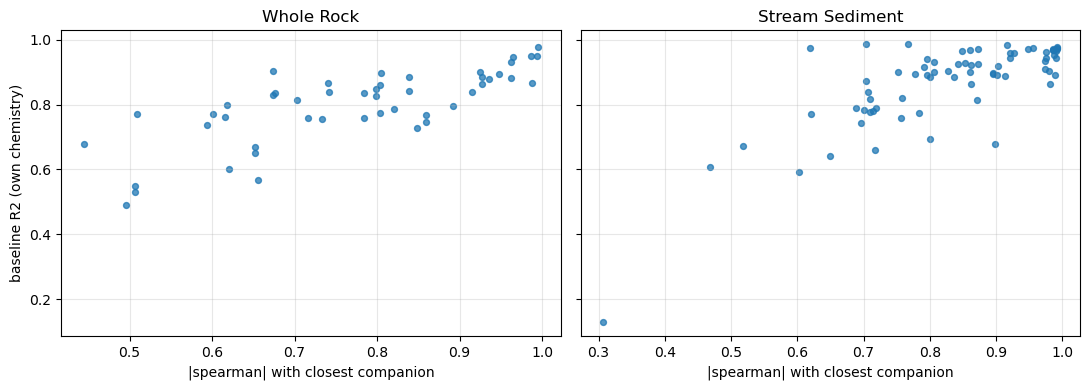

In [25]:
printable = Printable()
printable.title("Companion strength vs baseline R2")

for dataset in DATASETS:
    frame = companions[dataset].dropna(subset=["spearman", "baseline"])
    strength = frame["spearman"].abs()

    printable.add(dataset, f"{len(frame)} targets   "
                           f"pearson {pearsonr(strength, frame['baseline'])[0]:>+.3f}   "
                           f"spearman {spearmanr(strength, frame['baseline'])[0]:>+.3f}")
printable.flush()


fig, axes = plt.subplots(1, len(DATASETS), figsize=(11, 4), sharey=True)

for ax, dataset in zip(np.atleast_1d(axes), DATASETS):
    frame = companions[dataset].dropna(subset=["spearman", "baseline"])
    ax.scatter(frame["spearman"].abs(), frame["baseline"], s=18, alpha=0.75)
    ax.set_xlabel("|spearman| with closest companion")
    ax.set_title(dataset)
    ax.grid(alpha=0.3)

np.atleast_1d(axes)[0].set_ylabel("baseline R2 (own chemistry)")
plt.tight_layout()
plt.show()

### Export

A single flat file per dataset, so the report and any later session can quote numbers without
re-deriving them.

In [26]:
EXPORT_PATH = f"{DRIVE_PATH}Results/"


def ExportSummary():
    for dataset in DATASETS:
        frame = perElement[dataset].join(
            companions[dataset][["companion", "spearman", "n_partners_over_0.8"]]
            .rename(columns={"spearman": "companion_spearman"}),
            how="left")

        name = dataset.replace(" ", "-").lower()
        frame.round(4).to_csv(f"{EXPORT_PATH}per-element-{name}.csv", sep=";")
        print(f"wrote per-element-{name}.csv   ({len(frame)} rows)")

    headline.round(4).to_csv(f"{EXPORT_PATH}headline.csv", sep=";")
    print(f"wrote headline.csv   ({len(headline)} rows)")


ExportSummary()

wrote per-element-whole-rock.csv   (48 rows)
wrote per-element-stream-sediment.csv   (71 rows)
wrote headline.csv   (11 rows)


### Report Figures

Every figure in `Report/Report.pdf` is built here, from the same cached results the tables above
read. The implementation lives in `Report/make_figures.py` rather than in this cell, so that the
report and this notebook cannot drift apart — changing a figure there changes both, and
`python Report/make_figures.py` from the repository root does exactly what running this cell does.

`isolation.png` reads the per-element exports, so run **Export** above first on a fresh checkout.
The other five read the experiment JSONs directly.


samples.png  ->  Report\figures


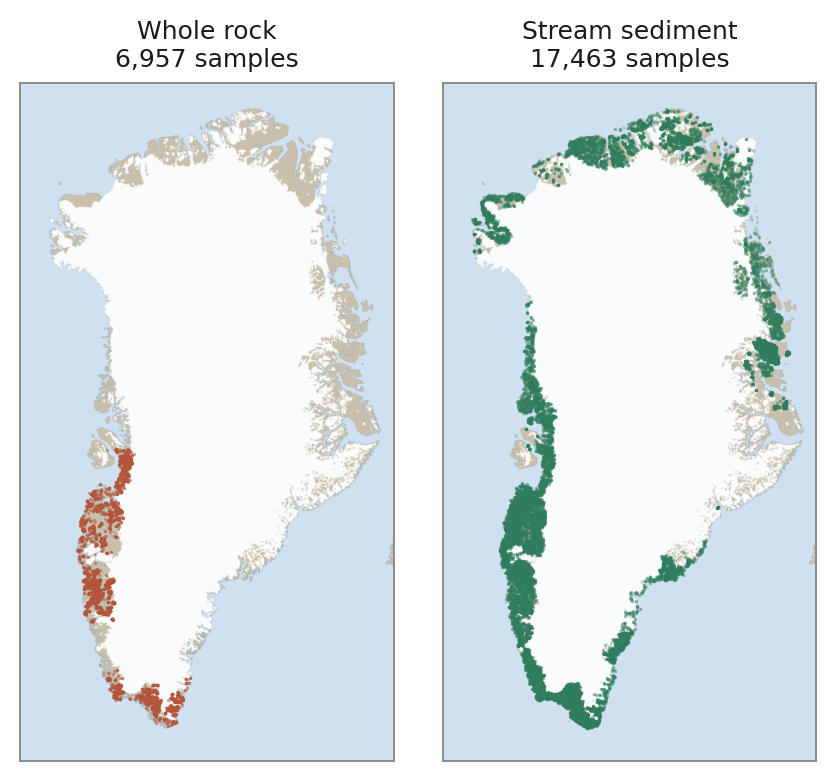

ksweep.png  ->  Report\figures


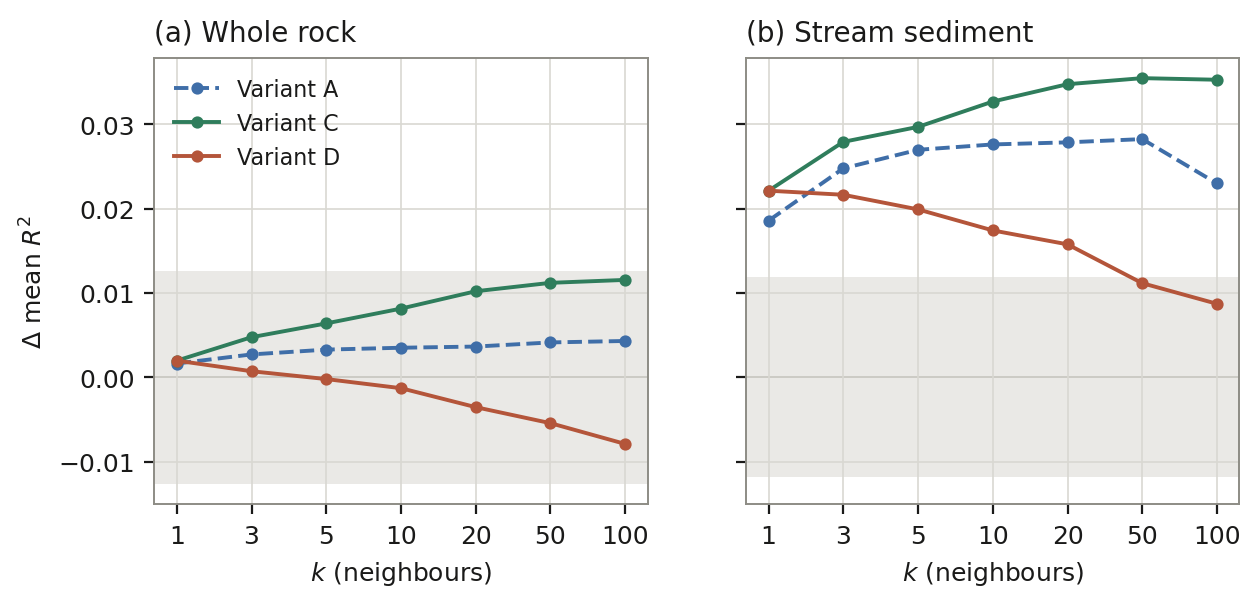

difficulty.png  ->  Report\figures


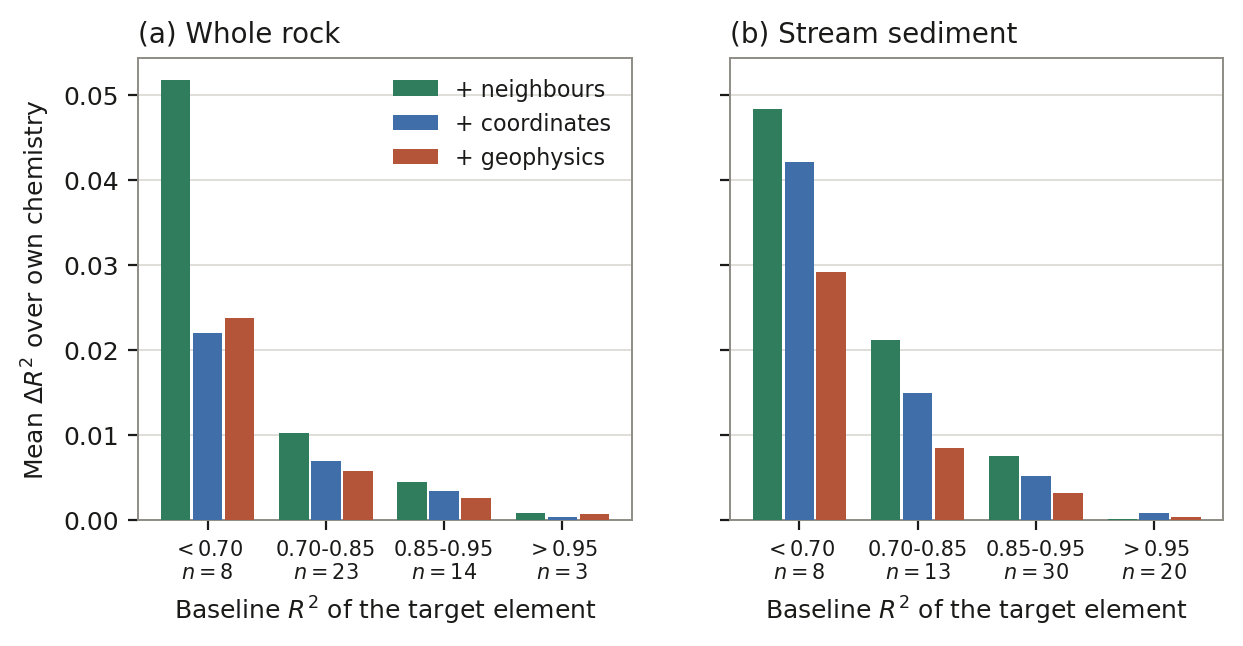

isolation.png  ->  Report\figures


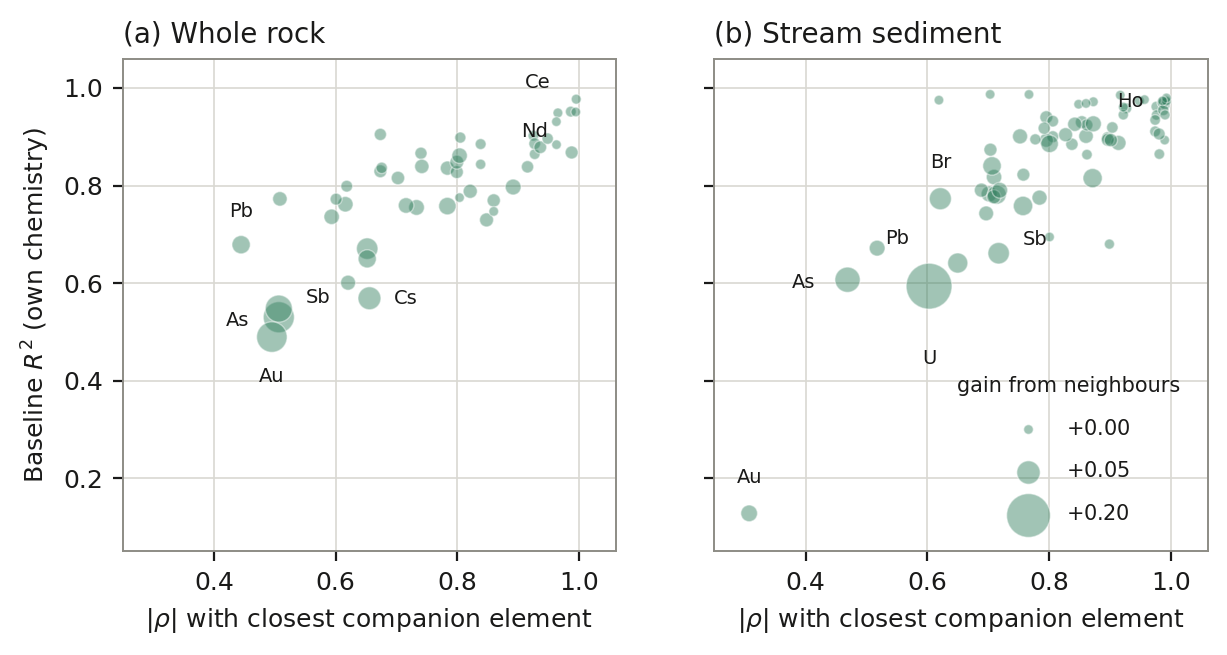

featuresets.png  ->  Report\figures


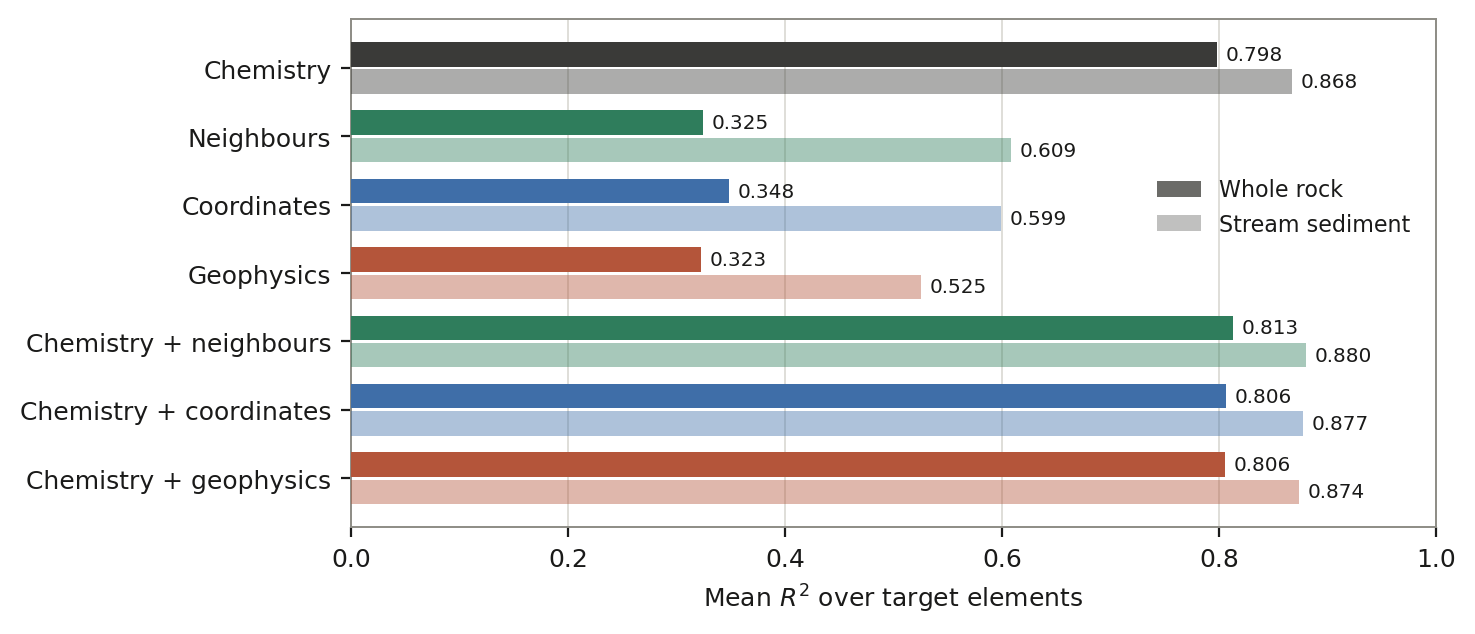

gnn.png  ->  Report\figures


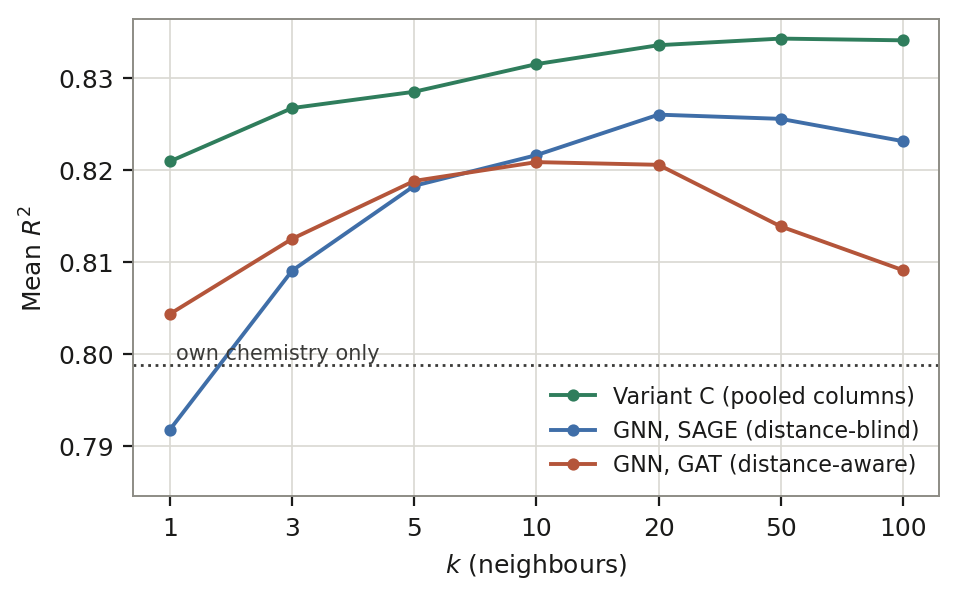

In [27]:
import importlib
from pathlib import Path

#Report/ is not on the path by default; on Colab it lives beside the rest of the mirror
sys.path.insert(0, f"{DRIVE_PATH}Report")

import make_figures
importlib.reload(make_figures)

#The module addresses everything from the repository root: the Drive mirror on Colab,
#the working directory otherwise
make_figures.ROOT = Path(DRIVE_PATH) if DRIVE_PATH else Path(".")

#Importing the module applies the report's Matplotlib style, so anything plotted after
#this cell inherits it
for name, Build in make_figures.FIGURES.items():
    figure = Build()
    print(f"{name}.png  ->  {make_figures.FiguresDir()}")
    display(figure)
    plt.close(figure)
